## For ViT:
- https://github.com/lucidrains/vit-pytorch/blob/main/vit_pytorch/vit.py
    
## For Transformer:
- https://github.com/hyunwoongko/transformer
    
## For this lab, you will need to install einops:

  **`pip install einops`**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


/home/sadalyom/.conda/envs/ErSE222/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

train_dataset = dsets.MNIST(root='./data', 
                            train=True, 
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='./data', 
                           train=False, 
                           transform=transforms.ToTensor())


batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

## Visualization

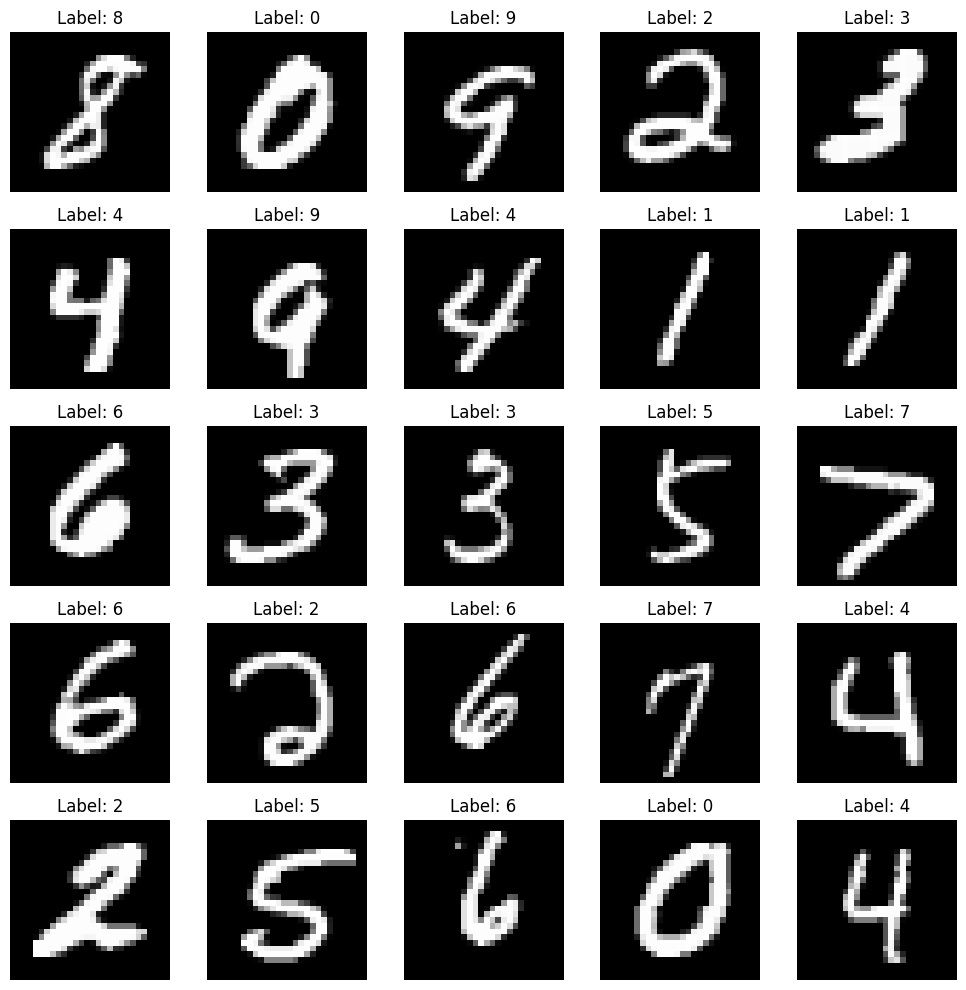

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and axis with 5x5 dimensions
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop through the train_loader to get samples
for i, (images, labels) in enumerate(train_loader):
    if i == 25:  # Only plot 25 images
        break
    
    # Display each image in the corresponding subplot
    ax = axes[i]
    ax.imshow(images[i].squeeze(), cmap='gray')  # Use squeeze to remove unnecessary dimensions
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')  # Turn off axis labels

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Create Model Class

In [18]:
import torch
from torch import nn

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# classes

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)

        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)

class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, img):
        x = self.to_patch_embedding(img)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

## Instantiate Model Class

In [19]:
model = ViT(
    image_size=28,
    patch_size=7,
    num_classes=10,
    dim=128,
    depth=6,
    heads=8,
    mlp_dim=256,
    channels=1,
    pool='cls',
    dim_head=64,
    dropout=0.1,
    emb_dropout=0.1
).to(device)

## Instantiate the loss and the Optimizer Classes

In [20]:
criterion = nn.CrossEntropyLoss()

learning_rate = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  

## Training Process

In [23]:
model.train()
iter = 0


for epoch in range(num_epochs):
    # Calculate Accuracy         
    correct = 0
    total = 0
    for i, (images, labels) in enumerate(train_loader):
        # Load images with gradient accumulation capabilities
        #images = images.view(-1, 28*28).requires_grad_(True)
        
        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()
        
        # Forward pass to get output/logits
        outputs = model(images.to(device))
        
        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels.to(device))
        
        # Getting gradients w.r.t. parameters
        loss.backward()
        
        # Updating parameters
        optimizer.step()
        

        # Get predictions from the maximum value
        _, predicted = torch.max(outputs.data, 1)

        # Total number of labels
        total += labels.shape[0]

        # Total correct predictions
        correct += (predicted == labels.to(device)).sum()
            
    accuracy = 100 * correct / total
            
    # Print Loss
    print('epoch: {}. Loss: {}. Training Accuracy: {}'.format(epoch, loss.item(), accuracy))

epoch: 0. Loss: 0.26321494579315186. Training Accuracy: 82.81999969482422
epoch: 1. Loss: 0.12003733962774277. Training Accuracy: 94.73833465576172
epoch: 2. Loss: 0.11373445391654968. Training Accuracy: 96.13333129882812
epoch: 3. Loss: 0.12485792487859726. Training Accuracy: 96.8183364868164
epoch: 4. Loss: 0.03934584558010101. Training Accuracy: 97.25


## Inference (Testing)

In [25]:

correct = 0
total = 0
# Iterate through test dataset
for images, labels in test_loader:
    # Load images with gradient accumulation capabilities
    #images = images.view(-1, 28*28).requires_grad_()

    # Forward pass only to get logits/output
    outputs = model(images.to(device))

    # Get predictions from the maximum value
    _, predicted = torch.max(outputs.data, 1)

    # Total number of labels
    total += labels.shape[0]

    # Total correct predictions
    correct += (predicted == labels.to(device)).sum()

accuracy = 100 * correct / total

# Print Loss
print('Loss: {}. Testing Accuracy: {}'.format(loss.item(), accuracy))

Loss: 0.03934584558010101. Testing Accuracy: 97.25999450683594


## Visualization the test set

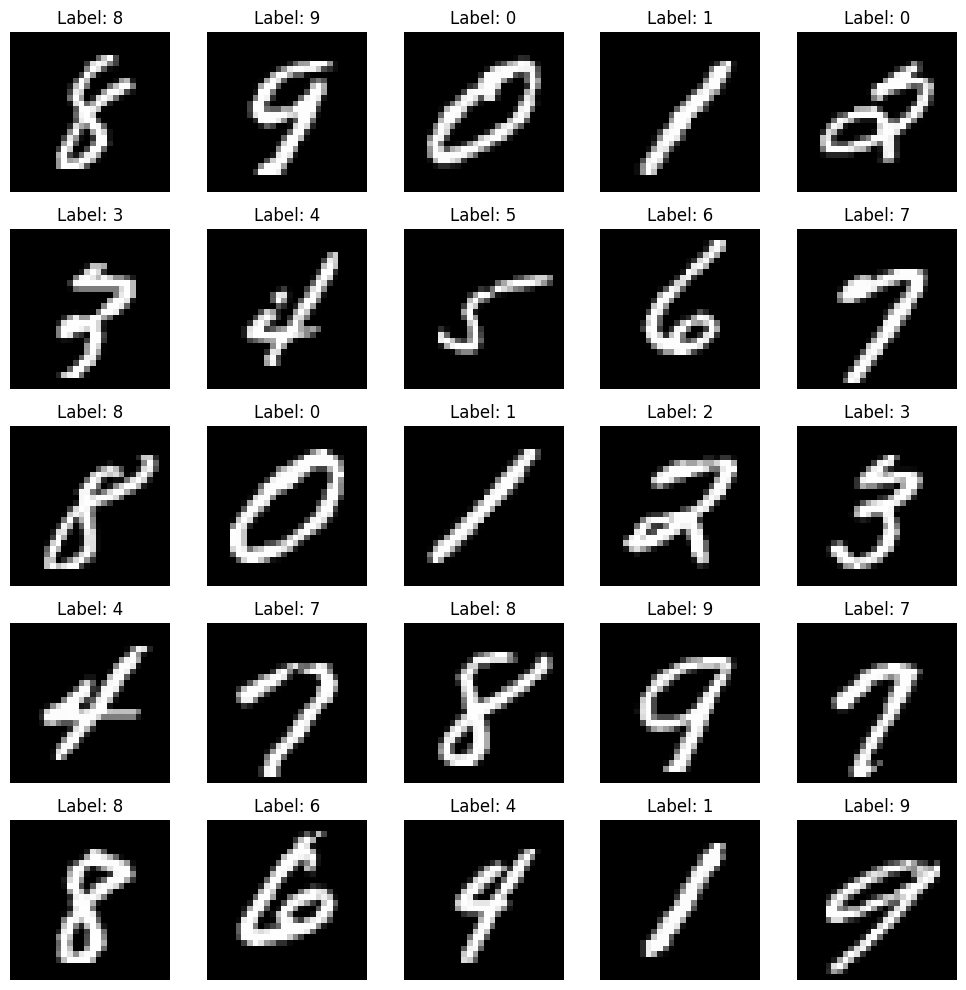

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and axis with 5x5 dimensions
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()  # Flatten the axes array for easy indexing
c = 0
# Loop through the train_loader to get samples
for image, lab in zip(images,outputs):
    if c==25:
        break
    
    # Display each image in the corresponding subplot
    ax = axes[c]
    ax.imshow(image.view(28,28).detach().numpy(), cmap='gray')  # Use squeeze to remove unnecessary dimensions
    ax.set_title(f'Label: {lab.argmax()}')
    ax.axis('off')  # Turn off axis labels
    c+=1
# Adjust layout and show the plot
plt.tight_layout()
plt.show()